# Data Scientist Take-Home Assignment — Housing Data

## 1. Assignment Understanding

The assignment asks us to work with the provided housing dataset and submit any two tasks from the following options:

1. Data Analysis and Visualization  
2. Predictive Modeling for `SalePrice`  
3. A conceptual real-estate recommender system design  

For this solution, I focused mainly on **Task 1: Exploratory Data Analysis** and **Task 2: Predictive Modeling**, because both tasks use the same dataset and allow us to move naturally

## 2. My Thinking Approach

Before building any model, I wanted to understand the dataset as if I were preparing a real business report. I did not want to jump directly into machine learning because a model can give good numbers while still hiding data quality issues, missing values, outliers, or business patterns.

My workflow was:

1. Load the dataset and check its shape.
2. Understand the target column, which is `SalePrice`.
3. Check missing values and decide how to handle them.
4. Explore important relationships between house features and sale price.
5. Create simple visualizations that can explain the findings.
6. Build a baseline model first, then compare it with stronger models.
7. Evaluate the final model using MAE, RMSE, and R².

## 3. Import Libraries


In [3]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

## 4. Load the Dataset

In [5]:
df=pd.read_csv('/content/housing_data_900.csv')

In [6]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (900, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1001,527131110,120,RL,45.0,6264,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,247900
1,1002,527140090,120,RL,41.0,5395,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,10,2008,WD,Normal,180000
2,1003,527145090,120,RL,39.0,5070,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,8,2008,WD,Normal,180000
3,1004,527161010,60,RL,100.0,10839,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,181000
4,1005,527162180,60,RL,73.0,11184,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2008,WD,Family,183000


## 5. Basic Data Inspection

In [7]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            900 non-null    int64  
 1   PID              900 non-null    int64  
 2   MS SubClass      900 non-null    int64  
 3   MS Zoning        900 non-null    object 
 4   Lot Frontage     734 non-null    float64
 5   Lot Area         900 non-null    int64  
 6   Street           900 non-null    object 
 7   Alley            65 non-null     object 
 8   Lot Shape        900 non-null    object 
 9   Land Contour     900 non-null    object 
 10  Utilities        900 non-null    object 
 11  Lot Config       900 non-null    object 
 12  Land Slope       900 non-null    object 
 13  Neighborhood     900 non-null    object 
 14  Condition 1      900 non-null    object 
 15  Condition 2      900 non-null    object 
 16  Bldg Type        900 non-null    object 
 17  House Style     

,count,mean,std,min,25%,50%,75%,max
Order,900.0,1.450500e+03,2.599519e+02,1001.0,1.225750e+03,1450.5,1.675250e+03,1.900000e+03
PID,900.0,6.681190e+08,1.820221e+08,526352080.0,5.282352e+08,534175075.0,9.052001e+08,1.007100e+09
MS SubClass,900.0,5.941111e+01,4.332712e+01,20.0,2.000000e+01,60.0,7.500000e+01,1.900000e+02
Lot Frontage,734.0,7.007902e+01,2.592253e+01,21.0,5.900000e+01,70.0,8.100000e+01,3.130000e+02
Lot Area,900.0,1.009840e+04,7.542998e+03,1477.0,7.466500e+03,9522.5,1.169550e+04,1.646600e+05
Overall Qual,900.0,6.340000e+00,1.396786e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,900.0,5.583333e+00,1.066608e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,900.0,1.976128e+03,2.910910e+01,1872.0,1.959000e+03,1978.0,2.003000e+03,2.008000e+03
Year Remod/Add,900.0,1.987369e+03,1.979549e+01,1950.0,1.971000e+03,1996.0,2.004000e+03,2.008000e+03
Mas Vnr Area,888.0,1.232658e+02,1.984067e+02,0.0,0.000000e+00,0.0,2.000000e+02,1.600000e+03


In [8]:
df["SalePrice"].describe()

,SalePrice
count,900.000000
mean,192203.651111
std,85313.945606
min,13100.000000
25%,136375.000000
50%,174000.000000
75%,226712.500000
max,755000.000000


The mean is higher than the median, which suggests that expensive houses are pulling the average upward.

## 6. Missing Values Check

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0].head(20)

,0
Pool QC,896
Misc Feature,867
Alley,835
Fence,752
Mas Vnr Type,497
Fireplace Qu,417
Lot Frontage,166
Garage Qual,44
Garage Yr Blt,44
Garage Cond,44


# Task 1 — Exploratory Data Analysis

## 7.1 Sale Price Distribution

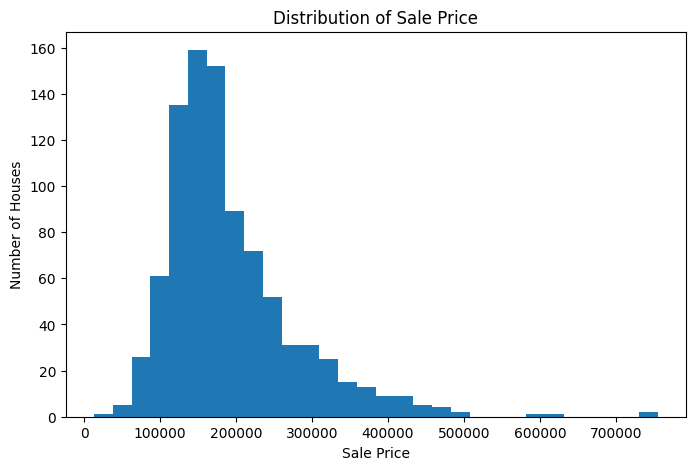

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=30)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.show()

Most houses are concentrated in the lower-to-mid price range, while a smaller number of expensive houses create a right-skewed distribution. Which means the model may benefit from trying a log transformation of SalePrice in a future improvement.

## 7.2 Sale Price vs Overall Quality

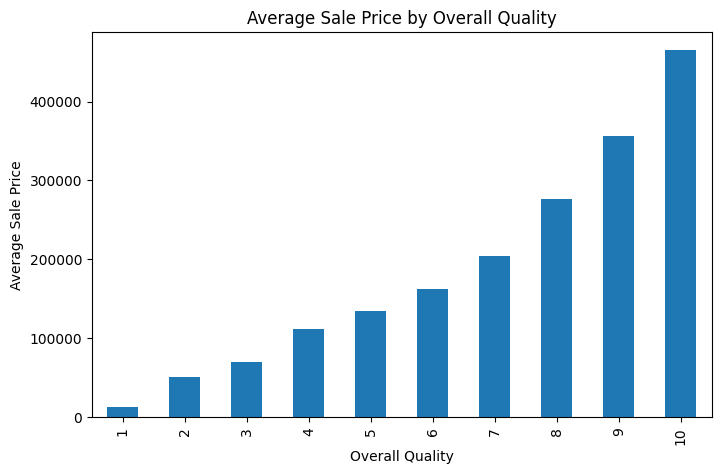

In [11]:
quality_price = df.groupby("Overall Qual")["SalePrice"].mean()

plt.figure(figsize=(8, 5))
quality_price.plot(kind="bar")
plt.title("Average Sale Price by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Average Sale Price")
plt.show()

 The graph shows that houses with higher quality ratings have much higher average sale prices. which means that Overall Qual is one of the strongest features in the dataset.

## 7.3 Sale Price vs Living Area

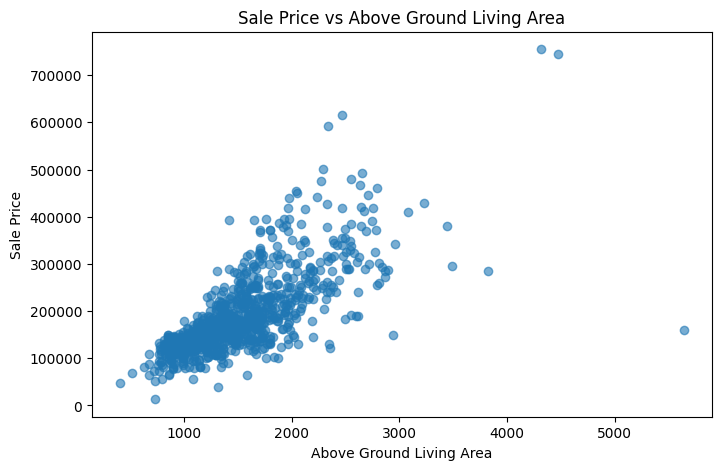

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.6)
plt.title("Sale Price vs Above Ground Living Area")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")
plt.show()

Larger houses usually sell for more, although there are some unusual points where very large homes do not have prices as high as expected.

## 7.4 Correlation with Sale Price

In [13]:
numeric_corr = df.select_dtypes(include=np.number).corr()["SalePrice"]
numeric_corr = numeric_corr.sort_values(ascending=False)

numeric_corr.head(12)

,SalePrice
SalePrice,1.000000
Overall Qual,0.795399
Gr Liv Area,0.723209
Garage Area,0.669825
Garage Cars,0.647759
Total Bsmt SF,0.640525
1st Flr SF,0.640095
Year Built,0.542092
Garage Yr Blt,0.530598
Fireplaces,0.529910


The most important drivers of price are quality, house size, garage capacity and basement size. Which makes sense from a real-estate point of view because buyers usually care about size, condition, and home features.

## 7.5 Neighborhood Price Differences

In [14]:
neighborhood_prices = (
    df.groupby("Neighborhood")["SalePrice"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

neighborhood_prices.head(10)

,count,mean
Neighborhood,,
NoRidge,31,342985.161290
NridgHt,74,321493.540541
StoneBr,21,301714.619048
Veenker,16,241481.250000
Timber,18,236579.611111
Somerst,92,233174.652174
Crawfor,21,222125.714286
Greens,1,213750.000000
ClearCr,11,205175.636364


Some neighborhoods have much higher average prices than others. However, I would be careful with neighborhoods that have very small sample sizes, such as Greens, because one house is not enough to represent a whole area.

## 8. EDA Summary for Non-Technical Stakeholders

The data shows that house sale price is mainly affected by overall quality, living area, garage size, basement size, and neighborhood. Better quality houses sell for much higher prices, and larger houses generally have higher values. The neighborhood also plays an important role, which means location should be treated as an important business feature, not just a category in the data. Also, some columns have many missing values, but many of these missing values mean the house does not have that feature, such as a pool, alley, or fireplace.

# Task 2 — Predictive Modeling

## 9. Model Goal

The goal is to predict SalePrice using the available historical housing features. This is a regression problem as the target value is a continuous number.

## 10. Data Preparation for Modeling

In [15]:
# I removed Order and PID because they are identifiers
X = df.drop(columns=["SalePrice", "Order", "PID"])
y = df["SalePrice"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

## 11. Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## 12. Preprocessing Pipeline

In [17]:
# Fill missing values in numeric columns using the median
numeric_preprocessing = SimpleImputer(strategy="median")

# Fill missing values in categorical columns using the most common value
categorical_imputer = SimpleImputer(strategy="most_frequent")

# Convert categorical text columns into numbers
categorical_encoder = OneHotEncoder(handle_unknown="ignore")

# Apply imputer then encoder on categorical columns
categorical_preprocessing = Pipeline([
    ("fill_missing_values", categorical_imputer),
    ("convert_to_numbers", categorical_encoder)
])

# Apply preprocessing to numeric and categorical columns
preprocessor = ColumnTransformer([
    ("numeric_columns", numeric_preprocessing, numeric_features),
    ("categorical_columns", categorical_preprocessing, categorical_features)
])

Median imputation is stable for numeric columns and is less affected by outliers than the mean.

One-hot encoding allows the model to use categorical variables like neighborhood, sale type, and house style.

## 13. Model Selection

In [18]:
# Preprocess the data first
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### 13.1 Ridge Regression Model

In [19]:
ridge_model = Ridge(alpha=10)

ridge_model.fit(X_train_processed, y_train)

ridge_predictions = ridge_model.predict(X_test_processed)

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Results")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Ridge Regression Results
MAE: 17747.175134409517
RMSE: 25491.816144963446
R2 Score: 0.8782595473559593


### 13.2 Random Forest Model

In [20]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=2,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

random_forest_predictions = random_forest_model.predict(X_test_processed)

random_forest_mae = mean_absolute_error(y_test, random_forest_predictions)
random_forest_rmse = np.sqrt(mean_squared_error(y_test, random_forest_predictions))
random_forest_r2 = r2_score(y_test, random_forest_predictions)

print("Random Forest Results")
print("MAE:", random_forest_mae)
print("RMSE:", random_forest_rmse)
print("R2 Score:", random_forest_r2)

Random Forest Results
MAE: 15304.193133392122
RMSE: 23750.609462743494
R2 Score: 0.8943224164382501


### 13.3 Gradient Boosting Model

In [21]:
gradient_boosting_model = GradientBoostingRegressor(random_state=42)

gradient_boosting_model.fit(X_train_processed, y_train)

gradient_boosting_predictions = gradient_boosting_model.predict(X_test_processed)

gradient_boosting_mae = mean_absolute_error(y_test, gradient_boosting_predictions)
gradient_boosting_rmse = np.sqrt(mean_squared_error(y_test, gradient_boosting_predictions))
gradient_boosting_r2 = r2_score(y_test, gradient_boosting_predictions)

print("Gradient Boosting Results")
print("MAE:", gradient_boosting_mae)
print("RMSE:", gradient_boosting_rmse)
print("R2 Score:", gradient_boosting_r2)

Gradient Boosting Results
MAE: 14139.04799659805
RMSE: 20995.50057149896
R2 Score: 0.9174179187156932


## 13.4 XGBoost Model

In [22]:
xgboost_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=1
)

xgboost_model.fit(X_train_processed, y_train)

xgboost_predictions = xgboost_model.predict(X_test_processed)

xgboost_mae = mean_absolute_error(y_test, xgboost_predictions)
xgboost_rmse = np.sqrt(mean_squared_error(y_test, xgboost_predictions))
xgboost_r2 = r2_score(y_test, xgboost_predictions)

print("XGBoost Results")
print("MAE:", xgboost_mae)
print("RMSE:", xgboost_rmse)
print("R2 Score:", xgboost_r2)

XGBoost Results
MAE: 14469.8232421875
RMSE: 21664.711952850885
R2 Score: 0.91206955909729


## 13.5 LightGBM **Model**

In [23]:
lightgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    verbose=-1,
    n_jobs=1
)

lightgbm_model.fit(X_train_processed, y_train)

lightgbm_predictions = lightgbm_model.predict(X_test_processed)

lightgbm_mae = mean_absolute_error(y_test, lightgbm_predictions)
lightgbm_rmse = np.sqrt(mean_squared_error(y_test, lightgbm_predictions))
lightgbm_r2 = r2_score(y_test, lightgbm_predictions)

print("LightGBM Results")
print("MAE:", lightgbm_mae)
print("RMSE:", lightgbm_rmse)
print("R2 Score:", lightgbm_r2)

LightGBM Results
MAE: 14384.823688988034
RMSE: 22606.944625355445
R2 Score: 0.9042547807200034


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 13.6 CatBoost Model

In [24]:
catboost_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    thread_count=1
)

catboost_model.fit(X_train_processed, y_train)

catboost_predictions = catboost_model.predict(X_test_processed)

catboost_mae = mean_absolute_error(y_test, catboost_predictions)
catboost_rmse = np.sqrt(mean_squared_error(y_test, catboost_predictions))
catboost_r2 = r2_score(y_test, catboost_predictions)

print("CatBoost Results")
print("MAE:", catboost_mae)
print("RMSE:", catboost_rmse)
print("R2 Score:", catboost_r2)

CatBoost Results
MAE: 14722.301374180775
RMSE: 21128.857670995403
R2 Score: 0.9163655139752247


# 14 Compare the Models

In [25]:
results_df = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        ridge_mae,
        random_forest_mae,
        gradient_boosting_mae
    ],
    "RMSE": [
        ridge_rmse,
        random_forest_rmse,
        gradient_boosting_rmse
    ],
    "R2 Score": [
        ridge_r2,
        random_forest_r2,
        gradient_boosting_r2
    ]
})

results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,14139.047997,20995.500571,0.917418
1,Random Forest,15304.193133,23750.609463,0.894322
0,Ridge Regression,17747.175134,25491.816145,0.878260


# 15. Final Model Choice

I would choose Gradient Boosting Regressor as the final model for this version.

As gradient Boosting gave the best test performance, with the lowest MAE and RMSE and the highest R² score. It also works well for structured tabular data because it can capture non-linear relationships between features, such as the combined effect of quality, size, and garage area.

The model reached an R² score of around 0.917, meaning it explained about 91.7% of the variation in sale prices on the test set.

# 16. Model Evaluation Explanation

I used three evaluation metrics:

MAE — Mean Absolute Error

MAE tells us the average absolute difference between predicted and actual house prices.

For the final model, the MAE was about 14,139, meaning the prediction is off by around 14K on average.

RMSE — Root Mean Squared Error

RMSE penalizes large mistakes more heavily. This is useful in housing price prediction because being very wrong on expensive properties is a bigger issue.

For the final model, the RMSE was about 20,996.

R² Score

R² tells us how much of the target variation the model can explain.

The final model scored 0.9174, which is strong for a first modeling version.